# TP Scan

## Setup

1. Select GPU as an execution environnement
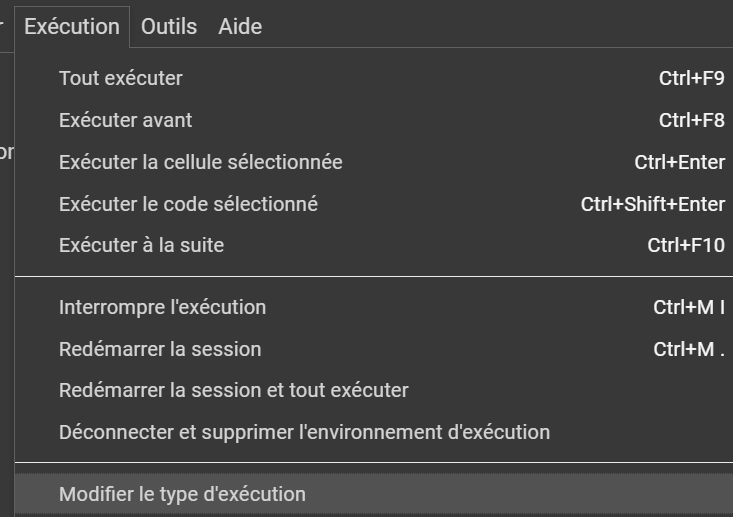
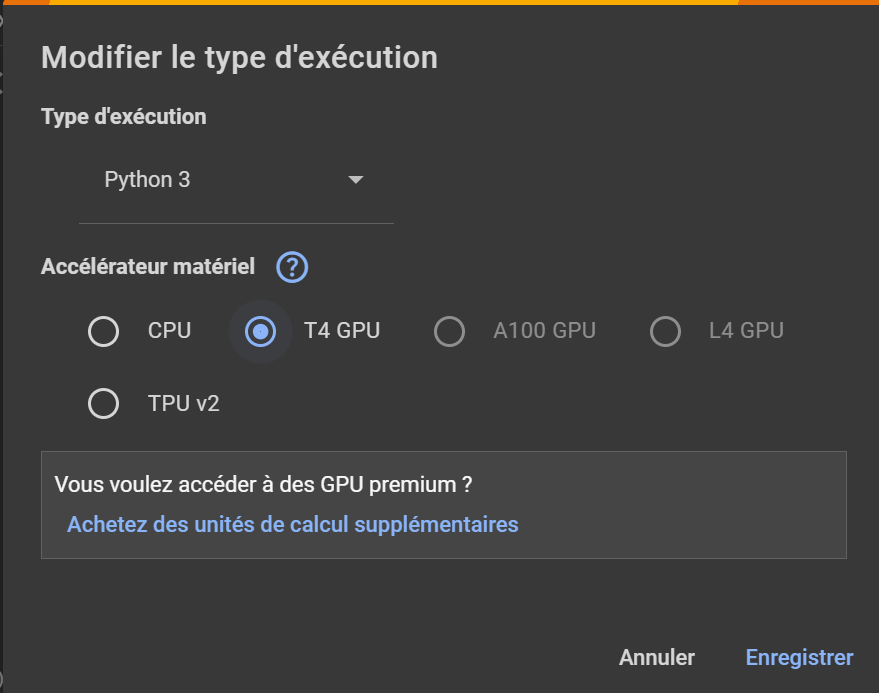

2. Check that the GPU is indeed detected (you should see nvidia-smi output with Tesla T4 as a GPU)

In [ ]:
!nvidia-smi

Wed Sep 16 19:30:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

3. Install conda (kernel will be restarted which is normal)

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


4. Install the conda env (should take around 4 minutes)

In [ ]:
!mamba install --no-pin -c nvidia -c conda-forge -c defaults cuda-version=13.0 cuda=13.0  benchmark cmake=3.30

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
nvidia/linux-64                                             Using cache
nvidia/noarch                                               Using cache
warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s
[+] 0.0s

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  Updating specs:

   - cuda-version=13.0
   - cuda=13.0
   - benchmark
   - cmake=3.30


  Package                             Version  Build                 Channel          Size
────────────────────────────────────────────────────────────────────────────────────────────
  Install:
────────────────────────────────────────────────────────────────────────────────────────────


5. Download the hands-on

In [ ]:
!git clone https://github.com/Kh4ster/tp_irgpua

Cloning into 'tp_irgpua'...
remote: Enumerating objects: 401, done.
remote: Counting objects: 100% (401/401), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 401 (delta 250), reused 294 (delta 144), pack-reused 0 (from 0)
Receiving objects: 100% (401/401), 72.83 KiB | 1.52 MiB/s, done.
Resolving deltas: 100% (250/250), done.


6. Verify compilation & execution (second test should fail)

In [ ]:
!cd tp_irgpua/tp_scan_cccl_only/ && mkdir build && cd build && cmake .. && make -j
!./tp_irgpua/tp_scan_cccl_only/build/bench

-- The CXX compiler identification is GNU 15.2.0
-- The CUDA compiler identification is NVIDIA 13.0.88
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/local/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Detecting CUDA compiler ABI info
-- Detecting CUDA compiler ABI info - done
-- Check for working CUDA compiler: /usr/local/bin/nvcc - skipped
-- Detecting CUDA compile features
-- Detecting CUDA compile features - done
-- Found CUDAToolkit: /usr/local/targets/x86_64-linux/include (found version "13.0.88")
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
-- The C compiler identification is GNU 15.2.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/local/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done


## Hands-On

There are 3 files you will continously modify during this hands-on through Colab's code box:

1. to_bench.cu : Add your successive scan implementation there
2. to_bench.cuh : Add the function signature there
3. main.cc : Add your new functions names (see TODO) and update the sizes when you need to

After have update the three file, you will compile, run and check the results.

After each success, move on with the next implementation / size (following shared hands-on instructions)

1. to_bench.cu : Add your successive scan implementation there

In [ ]:
%%file /content/tp_irgpua/tp_scan_cccl_only/src/to_bench.cu
#include "to_bench.cuh"

#include "cuda_tools/cuda_error_checking.cuh"

#include <cuda/std/span>

#include <cuda/buffer>

template <typename T>
__global__
void kernel_scan_baseline(cuda::std::span<T> buffer)
{
    for (int i = 1; i < buffer.size(); ++i)
        buffer[i] += buffer[i - 1];
}

void baseline_scan(cuda::device_buffer<int>& buffer)
{
	kernel_scan_baseline<int><<<1, 1, 0, buffer.stream().get()>>>(buffer);

    buffer.stream().sync();
}

template <typename T>
__global__
void kernel_your_scan(cuda::std::span<T> buffer)
{
    // TODO
    // ...
}

void your_scan(cuda::device_buffer<int>& buffer)
{
    // TODO
    // ...

	kernel_your_scan<int><<<1, 1, 0, buffer.stream().get()>>>(buffer);

    buffer.stream().sync();
}

Overwriting /content/tp_irgpua/tp_scan_cccl_only/src/to_bench.cu


2. to_bench.cuh : Add the function signature there

In [ ]:
%%file /content/tp_irgpua/tp_scan_cccl_only/src/to_bench.cuh
#pragma once

#include <cuda/buffer>

void baseline_scan(cuda::device_buffer<int>& buffer);

void your_scan(cuda::device_buffer<int>& buffer);

Overwriting /content/tp_irgpua/tp_scan_cccl_only/src/to_bench.cuh


3. main.cc : Add your new functions names (see TODO) and update the sizes when you need to

In [ ]:
%%file /content/tp_irgpua/tp_scan_cccl_only/bench/main.cc
#include "benchmark_registerer.hh"
#include "fixture.hh"
#include "main_helper.hh"
#include "to_bench.cuh"

#include <benchmark/benchmark.h>

int main(int argc, char** argv)
{
    // Google bench setup
    using benchmark_t = benchmark::Benchmark;
    ::benchmark::Initialize(&argc, argv);

    bool bench_nsight = parse_arguments(argc, argv);

    // Benchmarks registration
    Fixture fx;
    {
        // Add the sizes to benchmark here
        // Start with 1 block of 64 (block scan)
        // Then odd size (63)
        // Then 2 blocks of 64 each (grid scan)
        // Finally the true sizes
        // TODO
        constexpr std::array sizes = {
            64
            // 63,
            // 128,
            // 524288,
            // 1048576
        };

        // Add the name and function to benchmark here
        // TODO
        constexpr std::tuple scan_to_bench{
            "Baseline_scan",
            &baseline_scan,
            "Your_scan",
            &your_scan,
        };

        //  / 2 because we store name + function pointer
        benchmark_t* b[tuple_length(scan_to_bench) / 2];
        int function_index = 0;

        // Call to registerer
        registerer_scan(&fx,
                        b,
                        function_index,
                        sizes,
                        bench_nsight,
                        scan_to_bench);
    }
    ::benchmark::RunSpecifiedBenchmarks();
}


Overwriting /content/tp_irgpua/tp_scan_cccl_only/bench/main.cc


4. Compile and run

In [ ]:
!cd tp_irgpua/tp_scan_cccl_only && cd build && cmake .. && make -j && ./bench

-- Failed to find LLVM FileCheck
-- Google Benchmark version: v1.9.5-129-g82a89508, normalized to 1.9.5.129
-- CPM: Adding package CCCL@3.5.0. (v3.5.0.dev)
-- Finding CCCL components: Thrust;CUB;libcudacxx
-- Found CUB: /content/tp_irgpua/tp_scan_cccl_only/build/_deps/cccl-src/lib/cmake/cub/cub-config.cmake (found suitable version "3.5.0.0", minimum required is "3.5.0.0")
-- libcudacxx: - Assuming CUDA host compiler is the same as CXX compiler.
-- libcudacxx:   Set libcudacxx_MISMATCHED_HOST_COMPILER=TRUE to disable this.
-- Found libcudacxx: /content/tp_irgpua/tp_scan_cccl_only/build/_deps/cccl-src/lib/cmake/libcudacxx/libcudacxx-config.cmake (found suitable exact version "3.5.0.0")
-- Found Thrust: /content/tp_irgpua/tp_scan_cccl_only/build/_deps/cccl-src/lib/cmake/thrust/thrust-config.cmake (found suitable exact version "3.5.0.0")
-- Found libcudacxx: /content/tp_irgpua/tp_scan_cccl_only/build/_deps/cccl-src/lib/cmake/libcudacxx/libcudacxx-config.cmake (found version "3.5.0.0")
-- F

That's it! Go back to step 1. once it's working to add more code following the hands-on instruction.

Have fun!